Same analysis but for 3 **V1 (VISp)** containers. (`511507650`, `511509529`,
`511510650`)

Download the data

In [1]:
# !python scripts/download_container.py --containers 511507650 511509529 511510650 --out-dir ../data

---

In [2]:
%load_ext autoreload
%autoreload 2

from utils import *
plt.rcParams['figure.dpi'] = 100

# Load all V1 containers
data_list, cids = load_containers("data")
total_cells = sum(len(d["matched_cell_ids"]) for d in data_list)
print(f"Containers: {cids}")
print(f"Total cells pooled: {total_cells}")
for i, d in enumerate(data_list):
    print(f"  container {cids[i]}: {len(d['matched_cell_ids'])} cells")

Containers: [511507650, 511509529, 511510650]
Total cells pooled: 246
  container 511507650: 63 cells
  container 511509529: 116 cells
  container 511510650: 67 cells


# 1 Binary Modulation — V1 pooled population

In [3]:
# Run per container, then pool all per-cell results
all_bm = [run_binary_modulation_analysis(d, RESPONSE_WINDOWS) for d in data_list]

# Print per-container summary
for i, (bm, cid) in enumerate(zip(all_bm, cids)):
    summary = summarize_binary_modulation_runs(bm)
    print(f"\n--- Container {cid} ({summary['n_trials'].iloc[0]} trials DG) ---")
    print(summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]])

# Pool across containers
modulation_results = pool_binary_modulation(all_bm)
print(f"\nPooled: modulation_results ready for {list(modulation_results.keys())}")
modulated_mask = {stim: modulation_results[stim].modulated_mask for stim in STIMULI}
print(f"Total pooled cells: {len(modulated_mask['drifting_gratings'])})")


--- Container 511507650 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598         20       29        549
1    static_gratings      5804       5611       22        171
2     natural_scenes      5900       5332      144        424
3        spontaneous      1184        968       23        193

--- Container 511509529 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598        169      337         92
1    static_gratings      5804       1769     3742        293
2     natural_scenes      5900       2278     3352        270
3        spontaneous       593        252      298         43

--- Container 511510650 (598 trials DG) ---
            stimulus  n_trials  n_running  n_still  n_ignored
0  drifting_gratings       598         35      489         74
1    static_gratings      5806        215     5220        371
2     natural_scenes      5900        181     5128        5

/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


DG: 46/246 modulated
SG: 123/246 modulated
NS: 159/246 modulated
Spont: 8/246 modulated


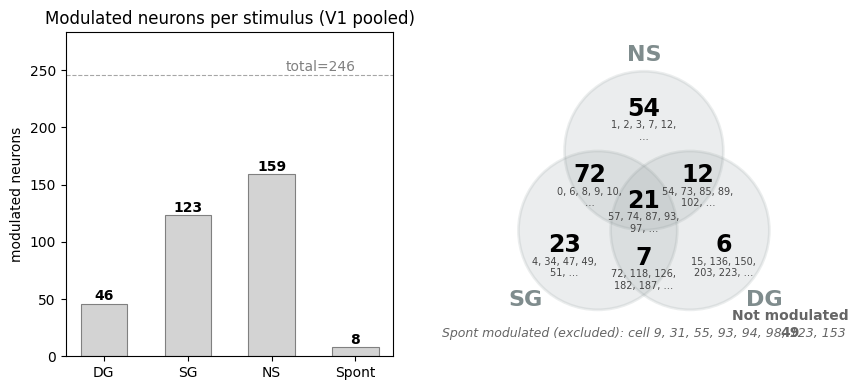

In [4]:
# Modulated neuron counts per stimulus
for stim in STIMULI:
    n_mod = int(modulated_mask[stim].sum())
    n_tot = len(modulated_mask[stim])
    print(f"{stim_to_short(stim)}: {n_mod}/{n_tot} modulated")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'width_ratios': [1, 1.3]})
plot_modulated_counts(modulated_mask, total_cells=total_cells, ax=ax1)
ax1.set_title('Modulated neurons per stimulus (V1 pooled)')
plot_modulated_venn(modulated_mask, ax=ax2)
plt.savefig("doc/figures/V1/V1_modulated_neurons_counts.png")
plt.show()

In [ ]:
# Sign-safe MI distributions
fig, axes = plot_metric_comparison(modulation_results, metric="mi", neurons_mask=modulated_mask)
fig.suptitle("Sign-safe MI — V1 pooled population", fontweight='bold')
plt.savefig("doc/figures/V1/V1_MI_histogram_populations.png", bbox_inches='tight')
plt.show()

In [ ]:
# Gain scatter — V1 pooled
fig = plot_gain_scatter(modulation_results, r2_threshold=0.2)
fig.suptitle("Gain (a, b) — V1 pooled population", fontweight='bold')
plt.savefig("doc/figures/V1/V1_gain_scatter.png", bbox_inches='tight')
plt.show()

In [7]:
# # Modulation grid — V1 pooled
# fig = plot_modulation_grid(modulation_results)
# fig.suptitle("V1 pooled", fontweight='bold')
# plt.savefig("doc/figures/V1/V1_modulation_grid.png")
# plt.show()

---

# 2 Speed Tuning — V1

In [8]:
# Extract trials and run SpeedTuning per container
mode = 'equal_size'
top_frac = 1

all_tunings = []  # list of {stim: SpeedTuning} per container

for idx, data in enumerate(data_list):
    trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
    pref_trial_masks = {stim: find_preferred_conditions(trial_data_dict[stim], top_frac)[1]
                        for stim in STIMULI[:-1]}
    pref_trial_masks["spontaneous"] = None

    # mod_mask per container
    bm = all_bm[idx]
    cont_mod_mask = {stim: bm[stim].modulated_mask for stim in STIMULI}

    tunings = {stim: SpeedTuning(
        trial_data_dict[stim], mode=mode,
        neuron_mask=cont_mod_mask[stim] if stim != 'spontaneous' else None,
        pref_trial_mask=pref_trial_masks[stim])
        for stim in STIMULI}

    for stim in STIMULI:
        tunings[stim].run()

    all_tunings.append(tunings)
    n_tuned = sum(int(tunings[s].significant_mask.sum()) for s in STIMULI[:3])
    print(f"Container {cids[idx]}: tuning done, {n_tuned} tuned (DG+SG+NS)")

print("\nAll containers processed.")

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:980: RuntimeWarning: Mean of empty slice
  self.mean_responses = np.nanmean(self.mean_all_responses, axis=0)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Container 511507650: tuning done, 53 tuned (DG+SG+NS)
Container 511509529: tuning done, 81 tuned (DG+SG+NS)
Container 511510650: tuning done, 19 tuned (DG+SG+NS)

All containers processed.


/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:980: RuntimeWarning: Mean of empty slice
  self.mean_responses = np.nanmean(self.mean_all_responses, axis=0)
/Users/eastos/miniforge3/envs/allensdk/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:
# Population tuning curves — overlay all containers per stimulus (mean ± SEM)
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
axf = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(cids)))

for j, stim in enumerate(STIMULI):
    ax = axf[j]
    for i, (tunings, cid) in enumerate(zip(all_tunings, cids)):
        tu = tunings[stim]
        mr = tu.mean_all_responses  # (n_cells, n_bins)
        m = np.nanmean(mr, axis=0)
        n_valid = np.sum(~np.isnan(mr), axis=0)
        sem = np.nanstd(mr, axis=0, ddof=0) / np.sqrt(n_valid.clip(min=1))
        ax.fill_between(tu.bins_centers, m - sem, m + sem,
                        color=colors[i], alpha=0.15, edgecolor='none')
        ax.plot(tu.bins_centers, m, color=colors[i], label=f'C{cid}',
                marker='o', markersize=3, markerfacecolor=colors[i],
                markeredgecolor=colors[i])
    ax.set_title(stim_to_short(stim))
    ax.set_xlabel('running speed (cm/s)')
    ax.set_ylabel('mean ΔF/F')
    if j == 0:
        ax.legend(fontsize=7)

fig.suptitle('Population tuning curves per container (V1)', fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuning_per_container.png", bbox_inches='tight')
plt.show()

In [ ]:
# Population tuning curves — pooled across all 3 containers (gray mean ± SEM)
N_COMMON_BINS = 20

# Build common speed grid across containers
common_grids = {}
for stim in STIMULI:
    speed_min = min(tunings[stim].bins_centers[0] for tunings in all_tunings)
    speed_max = max(tunings[stim].bins_centers[-1] for tunings in all_tunings)
    common_grids[stim] = np.linspace(speed_min, speed_max, N_COMMON_BINS)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
axf = axes.flatten()

for j, stim in enumerate(STIMULI):
    ax = axf[j]
    all_curves = []

    for i, tunings in enumerate(all_tunings):
        t = tunings[stim]
        mr = t.mean_all_responses  # (n_cells, n_bins)
        old_bins = t.bins_centers
        for ci in range(mr.shape[0]):
            y = mr[ci]
            if np.all(np.isnan(y)):
                continue
            new_y = np.interp(common_grids[stim], old_bins, y)
            new_y[common_grids[stim] < old_bins[0]] = np.nan
            new_y[common_grids[stim] > old_bins[-1]] = np.nan
            all_curves.append(new_y)

    arr = np.array(all_curves)  # (n_cells_pooled, n_bins_common)
    mu = np.nanmean(arr, axis=0)
    n_valid = np.sum(~np.isnan(arr), axis=0)
    sem = np.nanstd(arr, axis=0, ddof=0) / np.sqrt(n_valid.clip(min=1))

    ax.fill_between(common_grids[stim], mu - sem, mu + sem,
                    color='gray', alpha=0.2, edgecolor='none')
    ax.plot(common_grids[stim], mu, color='gray', linewidth=1.5,
            marker='o', markersize=3, markerfacecolor='gray',
            markeredgecolor='gray')
    ax.set_title(stim_to_short(stim))
    ax.set_xlabel('running speed (cm/s)')
    ax.set_ylabel('mean ΔF/F')

fig.suptitle('Population tuning curves — V1 pooled (total=246)', fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuning_pooled.png", bbox_inches='tight')
plt.show()

In [ ]:
# Monotonicity stacked bar per container
fig, axes = plt.subplots(1, len(cids), figsize=(4*len(cids), 4), constrained_layout=True)
if len(cids) == 1:
    axes = [axes]

for i, (tunings, ax) in enumerate(zip(all_tunings, axes)):
    cont_mod_mask = {stim: all_bm[i][stim].modulated_mask for stim in STIMULI}
    cont_total = len(data_list[i]["matched_cell_ids"])
    plot_monotonicity_stacked_bar(tunings, modulated_mask=cont_mod_mask, ax=ax)
    ax.set_title(f'Container {cids[i]} (total={cont_total})')   

fig.suptitle('Modulated & Tuned neurons (V1)', fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuned_neurons.png", bbox_inches='tight')
plt.show()

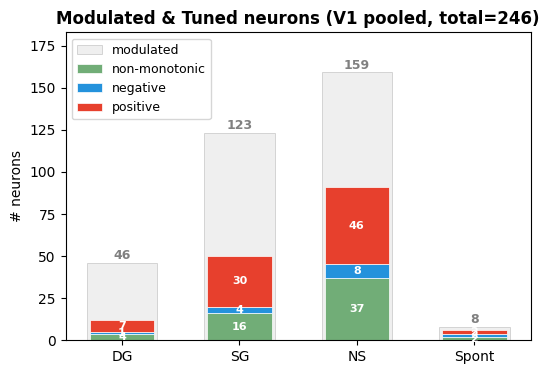

In [12]:
# Pooled monotonicity stacked bar — sum counts across all 3 containers
pooled_mod_counts = {stim: 0 for stim in STIMULI}
pooled_tuned = {stim: {'positive': 0, 'negative': 0, 'non-monotonic': 0}
                for stim in STIMULI}

for i, tunings in enumerate(all_tunings):
    cont_mod_mask = {stim: all_bm[i][stim].modulated_mask for stim in STIMULI}
    for stim in STIMULI:
        pooled_mod_counts[stim] += int(cont_mod_mask[stim].sum())
        t = tunings[stim]
        mm = cont_mod_mask[stim]
        n_tuning = len(t.monotonic_mask['positive'])
        if len(mm) != n_tuning:
            for c in ('positive', 'negative', 'non-monotonic'):
                pooled_tuned[stim][c] += int(t.monotonic_mask[c].sum())
        else:
            for c in ('positive', 'negative', 'non-monotonic'):
                pooled_tuned[stim][c] += int((t.monotonic_mask[c] & mm).sum())

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(pooled_mod_counts.keys())
categories = ['non-monotonic', 'negative', 'positive']
colors = {'positive': POS_COLOR, 'negative': NEG_COLOR, 'non-monotonic': NM_COLOR}

x = np.arange(len(labels))

# wider background bar: modulated
mod_vals = [pooled_mod_counts[l] for l in labels]
ax.bar(x, mod_vals, 0.6, color='lightgray', alpha=0.35,
       edgecolor='gray', linewidth=0.6, label='modulated', zorder=0)
for i, v in enumerate(mod_vals):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom',
            fontsize=9, color='gray', fontweight='bold')

# stacked tuned bars
bottom = np.zeros(len(labels))
for cat in categories:
    vals = [pooled_tuned[l][cat] for l in labels]
    ax.bar(x, vals, 0.55, bottom=bottom, label=cat,
           color=colors[cat], edgecolor='white', linewidth=0.5)
    bottom += vals

# segment labels
for i, lbl in enumerate(labels):
    y = 0.0
    for cat in categories:
        v = pooled_tuned[lbl][cat]
        if v > 0:
            ax.text(i, y + v / 2, str(v), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
        y += v

ax.set_xticks(x)
ax.set_xticklabels([stim_to_short(l) for l in labels])
ax.set_ylabel('# neurons')
ax.legend(fontsize=9)
ax.set_title(f'Modulated & Tuned neurons (V1 pooled, total={total_cells})', fontweight='bold')   
ax.margins(y=0.15)
plt.savefig("doc/figures/V1/V1_tuned_neurons_pooled.png")
plt.show()

## 2.2 Tuning profiles by monotonicity

Groups modulated neurons into: **positive**, **negative**, **non-monotonic** (significant ANOVA but monotonicity p > 0.05), and **non-tuned** (ANOVA p > 0.05). Spontaneous tuning of the same neurons is overlaid.

In [ ]:
# Tuning curves grouped by monotonicity — per container
import matplotlib.gridspec as gridspec

for cont_idx, (tunings, cid) in enumerate(zip(all_tunings, cids)):
    cont_mod_mask = {stim: all_bm[cont_idx][stim].modulated_mask for stim in STIMULI}

    fig = plt.figure(figsize=(13, 9))
    gs = gridspec.GridSpec(5, 4, height_ratios=[1, 1, 1, 0.06, 1], hspace=0.35)
    axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(4)]
                      for row in range(5)])
    for ax in axes[3]:
        ax.set_visible(False)

    for row in range(5):
        for col in range(4):
            if row != 3 and (row != 0 or col != 0):
                axes[row, col].sharex(axes[0, 0])
    for col in range(4):
        axes[0, col].tick_params(labelbottom=False)
        axes[1, col].tick_params(labelbottom=False)

    plot_rows = [0, 1, 2, 4]
    for plot_row, stim in zip(plot_rows, STIMULI):
        if stim == 'spontaneous':
            cells = np.where(cont_mod_mask['spontaneous'])[0]
            use_spont = None
        else:
            cells = None
            use_spont = tunings['spontaneous']
        tunings[stim].plot_tuning_by_monotonicity(
            axes=axes[plot_row], spontaneous=use_spont,
            modulated_mask=cont_mod_mask[stim], cells=cells)

        n_mod = int(cont_mod_mask[stim].sum()) if stim != 'spontaneous' else len(cells)
        axes[plot_row, 0].set_ylabel(f"{stim_to_short(stim)}\n({n_mod} mod)",
                                     fontsize=11, fontweight='bold')
        for ax in axes[plot_row]:
            ax.set_xlabel(None)

    for col in range(4):
        axes[4, col].set_xlabel('running speed (cm/s)')
        axes[2, col].tick_params(labelbottom=True)

    y_sep = (axes[2, 0].get_position().y0 + axes[4, 0].get_position().y1) / 2
    fig.lines.append(Line2D([0.08, 0.92], [y_sep, y_sep], color='gray',
                            linestyle='--', linewidth=1.2,
                            transform=fig.transFigure, clip_on=False))
    fig.suptitle(f'Tuning by monotonicity — Container {cid} (V1)',
                 fontsize=14, fontweight='bold')
    plt.savefig(f"doc/figures/V1/V1_tuning_by_monotonicity_C{cid}.png", bbox_inches='tight')
    plt.show()
    print(f"Container {cid} done.")

In [ ]:
# Pooled tuning curves — merge all 3 containers, common speed grid
# Matches per-container style: solid evoked, dashed+hollow spont, full titles
N_COMMON_BINS = 20

# 1. Per-stimulus common speed grid
common_grids = {}
for stim in STIMULI:
    speed_min = min(tunings[stim].bins_centers[0] for tunings in all_tunings)
    speed_max = max(tunings[stim].bins_centers[-1] for tunings in all_tunings)
    common_grids[stim] = np.linspace(speed_min, speed_max, N_COMMON_BINS)

# 2. Collect evoked + spont curves, monotonicity labels, and rho for all cells
#    Structure: pooled[stim] = {
#        'evoked':    list of arrays (interp to common bins),
#        'spont':     list of arrays (spont of same cells, interp to stim common bins),
#        'category':  list of 'positive'|'negative'|'non-monotonic'|'non_tuned',
#        'rho':       list of rho values,
#    }
pooled = {stim: {'evoked': [], 'spont': [], 'category': [], 'rho': []}
          for stim in STIMULI[:3]}  # DG, SG, NS only

for cont_idx, (tunings, bm) in enumerate(zip(all_tunings, all_bm)):
    spont_all = tunings['spontaneous'].mean_all_responses  # all cells
    spont_bins = tunings['spontaneous'].bins_centers

    for stim in STIMULI[:3]:  # DG, SG, NS
        t = tunings[stim]
        mod_mask_full = bm[stim].modulated_mask           # full-length bool mask
        evoked = t.mean_all_responses                      # (n_mod, n_bins)
        orig_idxs = np.where(mod_mask_full)[0]             # cell indices in spont_all

        # monotonicity 
        for cat in ('positive', 'negative', 'non-monotonic'):
            mask = t.monotonic_mask[cat]
            for j in np.where(mask)[0]:
                idx = orig_idxs[j]
                ev = np.interp(common_grids[stim], t.bins_centers, evoked[j])
                sp = np.interp(common_grids[stim], spont_bins, spont_all[idx])
                ev[common_grids[stim] < t.bins_centers[0]] = np.nan
                ev[common_grids[stim] > t.bins_centers[-1]] = np.nan
                sp[common_grids[stim] < spont_bins[0]] = np.nan
                sp[common_grids[stim] > spont_bins[-1]] = np.nan
                pooled[stim]['evoked'].append(ev)
                pooled[stim]['spont'].append(sp)
                pooled[stim]['category'].append(cat)
                pooled[stim]['rho'].append(t.rho[j])

        # non-tuned modulated = modulated but ANOVA not significant
        nt_mask = ~t.significant_mask  # within modulated pool
        for j in np.where(nt_mask)[0]:
            idx = orig_idxs[j]
            ev = np.interp(common_grids[stim], t.bins_centers, evoked[j])
            sp = np.interp(common_grids[stim], spont_bins, spont_all[idx])
            ev[common_grids[stim] < t.bins_centers[0]] = np.nan
            ev[common_grids[stim] > t.bins_centers[-1]] = np.nan
            sp[common_grids[stim] < spont_bins[0]] = np.nan
            sp[common_grids[stim] > spont_bins[-1]] = np.nan
            pooled[stim]['evoked'].append(ev)
            pooled[stim]['spont'].append(sp)
            pooled[stim]['category'].append('non_tuned')
            pooled[stim]['rho'].append(t.rho[j])

# 3. Spontaneous as a standalone row — cells from spont modulated mask
pooled_spont = {'evoked': [], 'category': [], 'rho': []}
for cont_idx, (tunings, bm) in enumerate(zip(all_tunings, all_bm)):
    t = tunings['spontaneous']
    mod_mask = bm['spontaneous'].modulated_mask  # full-length
    spont_cells = np.where(mod_mask)[0]
    for idx in spont_cells:
        ev = np.interp(common_grids['spontaneous'],
                       t.bins_centers, t.mean_all_responses[idx])
        ev[common_grids['spontaneous'] < t.bins_centers[0]] = np.nan
        ev[common_grids['spontaneous'] > t.bins_centers[-1]] = np.nan
        if np.isnan(ev).all():
            continue
        if t.monotonic_mask['positive'][idx]:
            cat = 'positive'
        elif t.monotonic_mask['negative'][idx]:
            cat = 'negative'
        elif t.monotonic_mask['non-monotonic'][idx]:
            cat = 'non-monotonic'
        else:
            cat = 'non_tuned'
        pooled_spont['evoked'].append(ev)
        pooled_spont['category'].append(cat)
        pooled_spont['rho'].append(t.rho[idx])

# 4. Plot — same layout as per-container: 5×4 grid, spacer at row 3
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(5, 4, height_ratios=[1, 1, 1, 0.06, 1], hspace=0.35)
axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(4)]
                  for row in range(5)])
for ax in axes[3]:
    ax.set_visible(False)

for row in range(5):
    for col in range(4):
        if row != 3 and (row != 0 or col != 0):
            axes[row, col].sharex(axes[0, 0])

cat_keys = ['non_tuned', 'non-monotonic', 'negative', 'positive'][::-1]
cat_colors = {
    'non_tuned': NTM_COLOR,
    'non-monotonic': NM_COLOR,
    'negative': NEG_COLOR,
    'positive': POS_COLOR,
}
cat_labels = ['non-tuned mod.', 'non-monotonic', 'negative', 'positive']

plot_rows = [0, 1, 2, 4]
for plot_row, stim in zip(plot_rows, STIMULI):
    bins = common_grids[stim]

    if stim == 'spontaneous':
        data = pooled_spont
        has_spont_overlay = False
    else:
        data = pooled[stim]
        has_spont_overlay = True

    if not data['evoked']:
        continue

    cats = np.array(data['category'])
    rhos = np.array(data['rho'])

    for ci, (cat, cat_label) in enumerate(zip(cat_keys, cat_labels)):
        ax = axes[plot_row, ci]
        mask = cats == cat
        n = mask.sum()

        if n == 0:
            continue

        ev_arr = np.array([data['evoked'][j] for j in np.where(mask)[0]])

        # spont baseline (dashed, hollow markers) — only for DG/SG/NS
        if has_spont_overlay:
            sp_arr = np.array([data['spont'][j] for j in np.where(mask)[0]])
            plot_mean_sem(ax, bins, sp_arr, cat_colors[cat], alpha=0.15,
                           linestyle='--', marker_facecolor='none')

        # evoked (solid, filled markers)
        plot_mean_sem(ax, bins, ev_arr, cat_colors[cat], alpha=0.5)

        # title with n, |rhō|
        rho_mean = np.abs(rhos[mask]).mean() if n > 0 else float('nan')
        rho_str = f'{rho_mean:.3f}'.replace('0.', '.', 1)
        ax.set_title(f'{cat_label} (n={n}, |$\\bar{{\\rho}}$|={rho_str})',
                     fontsize=9)
        ax.axhline(y=0, color='lightgray', linestyle='-', linewidth=0.5)

    axes[plot_row, 0].set_ylabel(stim_to_short(stim), fontsize=12, fontweight='bold')
    for ax in axes[plot_row]:
        ax.set_xlabel(None)

for col in range(4):
    axes[4, col].set_xlabel('running speed (cm/s)')
    axes[2, col].tick_params(labelbottom=True)
    axes[0, col].tick_params(labelbottom=False)
    axes[1, col].tick_params(labelbottom=False)

y_sep = (axes[2, 0].get_position().y0 + axes[4, 0].get_position().y1) / 2
fig.lines.append(Line2D([0.08, 0.92], [y_sep, y_sep], color='gray',
                         linestyle='--', linewidth=1.2,
                         transform=fig.transFigure, clip_on=False))

legend_handles = [
    Line2D([], [], color='black', marker='o', markersize=3,
           markerfacecolor='black', markeredgecolor='black'),
    Line2D([], [], color='black', marker='o', markersize=3,
           markerfacecolor='none', markeredgecolor='black',
           linestyle='--'),
]
fig.legend(legend_handles, ['Evoked', 'Spont'], loc='upper center',
           ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.96))

fig.suptitle('Tuning by monotonicity — V1 pooled (total=246)',
             fontsize=14, fontweight='bold')
plt.savefig("doc/figures/V1/V1_tuning_by_monotonicity_pooled.png", bbox_inches='tight')
plt.show()

In [ ]:
# Per-cell tuning grid map (Spearman rho + ANOVA p-value stars) per container
for cont_idx, (tunings, cid) in enumerate(zip(all_tunings, cids)):
    cont_mod_mask = {stim: all_bm[cont_idx][stim].modulated_mask for stim in STIMULI}
    fig = plot_modulated_tuned_grid(tunings, modulated_mask=cont_mod_mask, figsize=(7, 12))
    fig.suptitle(f'Modulated & Speed-Tuned Cells — Container {cid} (V1)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(f"doc/figures/V1/V1_tuning_profiles_C{cid}.png", bbox_inches='tight')
    plt.show()
    print(f"Container {cid} grid done.")